# Baseline Food Insecurity Risk Model

This notebook builds a baseline machine learning model for food insecurity early-warning analysis in Kenya ASAL counties.

The goal is to classify whether a county-period is high risk based on rainfall and NDVI vegetation indicators.

A county-period is treated as high risk if 20% or more of the population is in IPC Phase 3 or worse.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the master dataset
df = pd.read_csv("../02_data/processed/ipc_rainfall_ndvi_master_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (322, 19)


,ipc_date,analysis_period,county,max_ipc_phase,phase_3_plus_population,total_population,phase_3_plus_percentage,rainfall_date,mean_rainfall_mm,rainfall_3_month_total,rainfall_6_month_total,rainfall_3_month_avg,rainfall_6_month_avg,date,mean_ndvi,ndvi_1_month_mean,ndvi_3_month_mean,ndvi_6_month_mean,ndvi_anomaly
0,2019-07-01,Jul 2019,Baringo,4,105555,703697,0.15,2019-06-01,72.692665,143.441454,172.723779,47.813818,28.787296,2019-06-01,0.645498,0.645498,0.469621,0.424800,0.078739
1,2019-07-01,Jul 2019,Embu,3,32883,219220,0.15,2019-06-01,8.068131,123.946965,156.388124,41.315655,26.064687,2019-06-01,0.710059,0.710059,0.715939,0.708263,-0.026823
2,2019-07-01,Jul 2019,Garissa,4,151183,431950,0.35,2019-06-01,5.417682,55.185197,66.812339,18.395066,11.135390,2019-06-01,0.211246,0.211246,0.247841,0.247458,-0.047864
3,2019-07-01,Jul 2019,Isiolo,4,54413,155465,0.35,2019-06-01,0.936229,26.591658,40.062429,8.863886,6.677072,2019-06-01,0.207090,0.207090,0.223339,0.220767,-0.042075
4,2019-07-01,Jul 2019,Kajiado,3,43536,870721,0.05,2019-06-01,6.391582,62.716861,88.344720,20.905620,14.724120,2019-06-01,0.379489,0.379489,0.389526,0.366431,-0.030230


## Check Food Insecurity Burden Distribution

Before creating the machine learning target, I first check the distribution of `phase_3_plus_percentage`.

This helps decide whether the 20% threshold is reasonable for defining high-risk food insecurity cases.

In [5]:
# Check summary statistics for Phase 3+ population percentage
df["phase_3_plus_percentage"].describe()

count    322.000000
mean       0.146365
std        0.124900
min        0.000000
25%        0.050000
50%        0.100000
75%        0.200000
max        0.550000
Name: phase_3_plus_percentage, dtype: float64

### Interpretation

The `phase_3_plus_percentage` variable shows the share of the county population in IPC Phase 3 or worse.

The average value is about 14.6%, while the median is 10%. The 75th percentile is 20%, meaning that about one quarter of the records are at or above this level.

This makes the 20% threshold a reasonable starting point for defining high-risk food insecurity cases. It focuses the model on county-periods where food insecurity burden is widespread, not just present in a small part of the population.

In [6]:
# Exact split at 20%
threshold = 0.20
df['high_risk'] = (df['phase_3_plus_percentage'] >= threshold).astype(int)

print("High Risk Distribution:")
print(df['high_risk'].value_counts())
print("\nPercentages:")
print(df['high_risk'].value_counts(normalize=True) * 100)

High Risk Distribution:
high_risk
0    230
1     92
Name: count, dtype: int64

Percentages:
high_risk
0    71.428571
1    28.571429
Name: proportion, dtype: float64


### Interpretation

Using the 20% Phase 3+ population threshold, the dataset contains 230 non-high-risk records and 92 high-risk records.

This means about 71.4% of the records are non-high-risk, while about 28.6% are high-risk.

The split is not perfectly balanced, but it is reasonable for a baseline classification model. There are enough high-risk examples for the model to learn from, while the target still focuses on serious and widespread food insecurity cases.

## Time-Aware Train-Test Split

Because this is an early-warning project, the model should learn from past records and test on later records.

Instead of randomly splitting the data, I split the dataset by IPC date.

This makes the test closer to a real forecasting situation, where the model uses older data to predict future food insecurity risk.

In [7]:
# Convert IPC date to datetime format
df["ipc_date"] = pd.to_datetime(df["ipc_date"])

# Sort records by IPC date
df = df.sort_values("ipc_date").reset_index(drop=True)

# Use the first 80% of time-ordered records for training
# and the latest 20% for testing
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

# Select environmental predictor features
feature_cols = [
    "mean_rainfall_mm",
    "rainfall_3_month_total",
    "rainfall_6_month_total",
    "rainfall_3_month_avg",
    "rainfall_6_month_avg",
    "mean_ndvi",
    "ndvi_1_month_mean",
    "ndvi_3_month_mean",
    "ndvi_6_month_mean",
    "ndvi_anomaly"
]

X_train = train_df[feature_cols]
y_train = train_df["high_risk"]

X_test = test_df[feature_cols]
y_test = test_df["high_risk"]

print("=" * 50)
print("TRAIN SET")
print(f"Rows: {len(train_df)}")
print(f"Date range: {train_df['ipc_date'].min()} to {train_df['ipc_date'].max()}")
print(f"High Risk: {y_train.sum()} ({y_train.mean() * 100:.1f}%)")

print("\nTEST SET")
print(f"Rows: {len(test_df)}")
print(f"Date range: {test_df['ipc_date'].min()} to {test_df['ipc_date'].max()}")
print(f"High Risk: {y_test.sum()} ({y_test.mean() * 100:.1f}%)")

print("\n" + "=" * 50)
print("FEATURES USED:")
for feature in feature_cols:
    print(f"- {feature}")

TRAIN SET
Rows: 257
Date range: 2019-07-01 00:00:00 to 2025-02-01 00:00:00
High Risk: 76 (29.6%)

TEST SET
Rows: 65
Date range: 2025-02-01 00:00:00 to 2026-02-01 00:00:00
High Risk: 16 (24.6%)

FEATURES USED:
- mean_rainfall_mm
- rainfall_3_month_total
- rainfall_6_month_total
- rainfall_3_month_avg
- rainfall_6_month_avg
- mean_ndvi
- ndvi_1_month_mean
- ndvi_3_month_mean
- ndvi_6_month_mean
- ndvi_anomaly


### Interpretation

The dataset was split in time order, not randomly.

The training set contains 257 rows from July 2019 to February 2025. Out of these, 76 records are high-risk cases, representing 29.6% of the training data.

The test set contains 65 rows from February 2025 to February 2026. Out of these, 16 records are high-risk cases, representing 24.6% of the test data.

This split is reasonable because both the training and test sets contain high-risk and non-high-risk examples. The model can learn from past records and then be evaluated on later records, which is closer to a real early-warning situation.

## Naive Baseline Model

Before training machine learning models, I create a naive baseline model.

A naive baseline is a simple model that does not learn from rainfall, NDVI, or any other feature. It only predicts the most common class from the training data.

In this project, the most common class is usually:

- `0` = Not High Risk

This baseline is important because it gives us a minimum benchmark. Any useful machine learning model should perform better than this simple baseline.

Accuracy alone can be misleading in this project because most records are not high risk. A model can get reasonable accuracy by always predicting "Not High Risk", but that would be useless if it fails to identify real high-risk cases.

For this early-warning project, recall is especially important because missing a real high-risk case is more serious than raising a false alarm.

In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Create naive baseline model
naive_model = DummyClassifier(
    strategy="most_frequent",
    random_state=42
)

# Train the naive model
naive_model.fit(X_train, y_train)

# Make predictions
y_pred_naive = naive_model.predict(X_test)

# Predict probabilities for ROC-AUC
y_pred_prob_naive = naive_model.predict_proba(X_test)[:, 1]

# Evaluate naive baseline
naive_results = {
    "accuracy": accuracy_score(y_test, y_pred_naive),
    "precision": precision_score(y_test, y_pred_naive, zero_division=0),
    "recall": recall_score(y_test, y_pred_naive, zero_division=0),
    "f1_score": f1_score(y_test, y_pred_naive, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_pred_prob_naive)
}

naive_results

{'accuracy': 0.7538461538461538,
 'precision': 0.0,
 'recall': 0.0,
 'f1_score': 0.0,
 'roc_auc': 0.5}

### Interpretation

The naive baseline achieved about 75.4% accuracy by always predicting the most common class, which is `Not High Risk`.

However, this model failed to identify any true high-risk cases. Its precision, recall, and F1-score are all 0. This means it is not useful for an early-warning system.

The ROC-AUC score is 0.5, meaning the model has no real ability to separate high-risk cases from non-high-risk cases.

This shows why accuracy alone is misleading. A model can appear accurate while still failing at the most important task: identifying real high-risk food insecurity cases.

## Baseline Model 1: Logistic Regression

The first baseline model is Logistic Regression.

This model tries to predict whether a county-period is high risk or not high risk using rainfall and NDVI features.

Logistic Regression is a good starting point because it is simple, fast, and easier to interpret than more complex models.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Create the Logistic Regression model
log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# Train the model
log_model.fit(X_train, y_train)

# Make predictions
y_pred_log = log_model.predict(X_test)

# Predict probabilities for AUC-ROC
y_pred_prob_log = log_model.predict_proba(X_test)[:, 1]

# Evaluate the model
log_results = {
    "accuracy": accuracy_score(y_test, y_pred_log),
    "precision": precision_score(y_test, y_pred_log),
    "recall": recall_score(y_test, y_pred_log),
    "f1_score": f1_score(y_test, y_pred_log),
    "roc_auc": roc_auc_score(y_test, y_pred_prob_log)
}

log_results

{'accuracy': 0.7692307692307693,
 'precision': 0.5172413793103449,
 'recall': 0.9375,
 'f1_score': 0.6666666666666666,
 'roc_auc': 0.9170918367346939}

### Interpretation

The baseline Logistic Regression model performs well for a first early-warning model.

The model achieved about 76.9% accuracy, which is higher than the simple majority-class baseline of 71.4%. However, accuracy alone is not the most important metric for this project.

The most important result is recall. The model achieved about 93.8% recall, meaning it correctly identified most of the true high-risk cases in the test set. This is important because an early-warning system should avoid missing real food insecurity crises.

Precision is lower at about 51.7%, meaning the model also produced some false alarms. In a humanitarian early-warning context, this may be acceptable because a false alarm is usually less harmful than missing a real crisis.

The ROC-AUC score is about 91.7%, which suggests that rainfall and NDVI features contain useful signal for separating high-risk and non-high-risk county-periods.

Overall, this first baseline model is promising. It shows that environmental indicators can help identify food insecurity risk, but the model should be improved and compared with other models before being used for decision-making.

## Confusion Matrix

The confusion matrix shows how many predictions the model got right and wrong.

It helps us understand:

- how many low-risk cases were correctly predicted
- how many high-risk cases were correctly predicted
- how many false alarms happened
- how many real high-risk cases were missed

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix for Logistic Regression
cm = confusion_matrix(y_test, y_pred_log)

cm

array([[35, 14],
       [ 1, 15]])

### Interpretation

The confusion matrix shows how the Logistic Regression model performed on the test set.

The model correctly predicted 35 low-risk cases and 15 high-risk cases. It produced 14 false alarms and missed only 1 real high-risk case.

This means the model was very strong at catching high-risk cases, which is important for an early-warning system. The trade-off is that it also raised some false alarms.

For food insecurity early-warning, this behavior may be acceptable because missing a real high-risk county-period can be more harmful than flagging a county for closer monitoring.

## Confusion Matrix Visualization

The table above gives the raw confusion matrix numbers.  
This chart makes the same result easier to read visually.

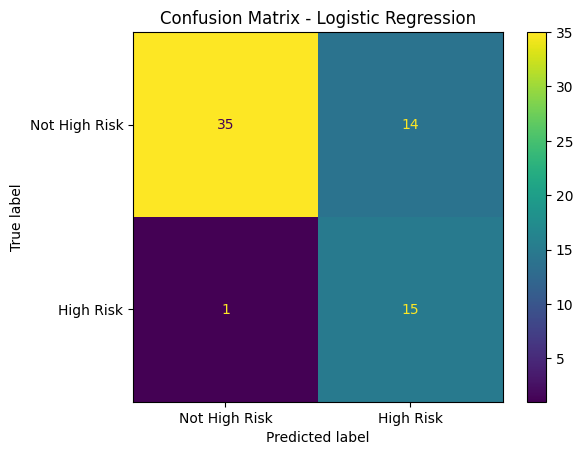

In [11]:
# Visualize confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not High Risk", "High Risk"]
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Interpretation

The confusion matrix visualization confirms that the model correctly identified most high-risk cases.

The model caught 15 out of 16 true high-risk cases and missed only 1 high-risk case. This is important for an early-warning system because missing a real crisis can be costly.

The model also produced 14 false alarms. This means some non-high-risk cases were flagged as high risk. In a humanitarian setting, this may still be acceptable because false alarms can lead to closer monitoring, while missed crises can delay response.

## Feature Importance from Logistic Regression

Logistic Regression gives each feature a coefficient.

A coefficient shows how strongly a feature influences the model prediction.

Positive coefficients increase the chance of a high-risk prediction.  
Negative coefficients reduce the chance of a high-risk prediction.

This helps us understand which rainfall and NDVI features the model relied on most.

In [12]:
# Create a table of Logistic Regression coefficients
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": log_model.coef_[0]
})

# Add absolute coefficient value to see strongest effects
feature_importance["absolute_coefficient"] = feature_importance["coefficient"].abs()

# Sort by strongest influence
feature_importance = feature_importance.sort_values(
    "absolute_coefficient",
    ascending=False
)

feature_importance

,feature,coefficient,absolute_coefficient
8,ndvi_6_month_mean,-1.539646,1.539646
7,ndvi_3_month_mean,-1.416079,1.416079
5,mean_ndvi,-0.736449,0.736449
6,ndvi_1_month_mean,-0.736449,0.736449
9,ndvi_anomaly,-0.248978,0.248978
0,mean_rainfall_mm,-0.028219,0.028219
2,rainfall_6_month_total,-0.024052,0.024052
1,rainfall_3_month_total,0.016594,0.016594
3,rainfall_3_month_avg,0.005531,0.005531
4,rainfall_6_month_avg,-0.004009,0.004009


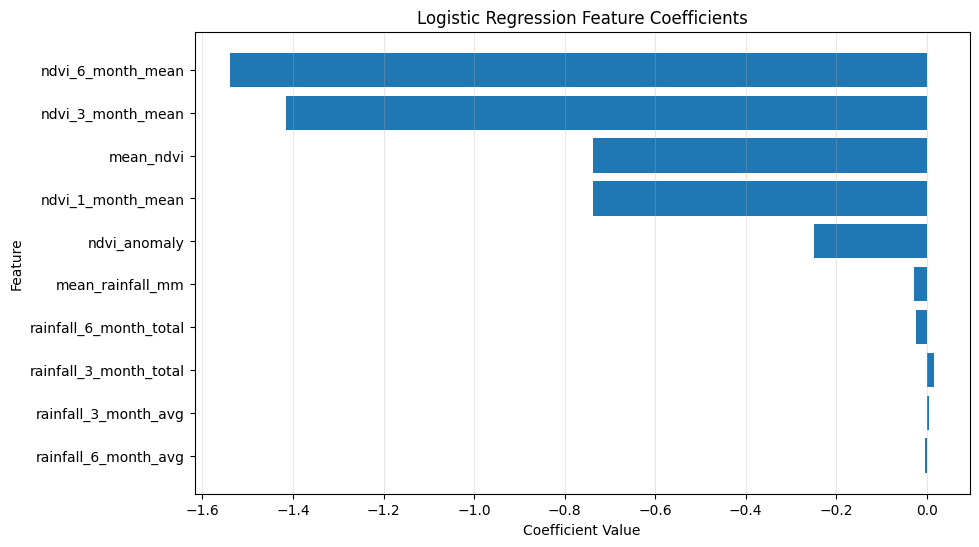

In [13]:
# Visualize Logistic Regression feature coefficients
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"],
    feature_importance["coefficient"]
)

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

plt.show()

### Interpretation

The Logistic Regression coefficients show that NDVI features had the strongest influence on the model's predictions.

The strongest coefficients are from `ndvi_6_month_mean`, `ndvi_3_month_mean`, `mean_ndvi`, and `ndvi_1_month_mean`. These coefficients are negative, meaning that higher NDVI values reduce the model's likelihood of predicting high food insecurity risk.

This makes sense because higher NDVI usually indicates greener and healthier vegetation, while lower NDVI suggests vegetation stress. Therefore, weaker vegetation health is associated with higher food insecurity risk.

Rainfall coefficients are smaller in this model. This does not mean rainfall is unimportant. It may be partly because rainfall variables use a different scale from NDVI and because several rainfall features are closely related to each other.

Overall, the model supports the earlier EDA finding that NDVI is one of the strongest environmental signals for food insecurity risk in this dataset.

## Baseline Model 2: Standardized Logistic Regression

The first Logistic Regression model used the raw feature values.

However, rainfall and NDVI are measured on different scales. Rainfall values can be much larger, while NDVI values are usually between 0 and 1.

To make the coefficients easier to compare, I train another Logistic Regression model using standardized features.

Standardization transforms each feature so that it has a similar scale.

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Create a pipeline that standardizes features before Logistic Regression
standardized_log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# Train the standardized Logistic Regression model
standardized_log_model.fit(X_train, y_train)

# Make predictions
y_pred_standardized = standardized_log_model.predict(X_test)

# Predict probabilities for ROC-AUC
y_pred_prob_standardized = standardized_log_model.predict_proba(X_test)[:, 1]

# Evaluate the standardized model
standardized_log_results = {
    "accuracy": accuracy_score(y_test, y_pred_standardized),
    "precision": precision_score(y_test, y_pred_standardized),
    "recall": recall_score(y_test, y_pred_standardized),
    "f1_score": f1_score(y_test, y_pred_standardized),
    "roc_auc": roc_auc_score(y_test, y_pred_prob_standardized)
}

standardized_log_results

{'accuracy': 0.7692307692307693,
 'precision': 0.5172413793103449,
 'recall': 0.9375,
 'f1_score': 0.6666666666666666,
 'roc_auc': 0.9298469387755102}

### Interpretation

The standardized Logistic Regression model produced almost the same classification results as the raw Logistic Regression model.

Accuracy, precision, recall, and F1-score remained the same. ROC-AUC improved slightly, suggesting that standardization helped the model rank high-risk cases a little better.

This means the baseline Logistic Regression model is stable. The model continues to show strong recall, meaning it is good at identifying most true high-risk cases.

Because standardized features make coefficients easier to compare, the standardized model is useful for interpreting feature influence.

## Standardized Feature Coefficients

Because the standardized Logistic Regression model uses scaled features, its coefficients are easier to compare.

This helps identify which rainfall and NDVI indicators had the strongest influence on the model after putting all features on a similar scale.

In [15]:
# Get the trained Logistic Regression model from the pipeline
standardized_model = standardized_log_model.named_steps["model"]

# Create coefficient table
standardized_feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": standardized_model.coef_[0]
})

# Add absolute coefficient to rank strongest influence
standardized_feature_importance["absolute_coefficient"] = (
    standardized_feature_importance["coefficient"].abs()
)

# Sort by strongest influence
standardized_feature_importance = standardized_feature_importance.sort_values(
    "absolute_coefficient",
    ascending=False
)

standardized_feature_importance

,feature,coefficient,absolute_coefficient
8,ndvi_6_month_mean,-1.157314,1.157314
0,mean_rainfall_mm,-0.869604,0.869604
7,ndvi_3_month_mean,-0.860049,0.860049
4,rainfall_6_month_avg,-0.689049,0.689049
2,rainfall_6_month_total,-0.689049,0.689049
1,rainfall_3_month_total,0.433071,0.433071
3,rainfall_3_month_avg,0.433071,0.433071
5,mean_ndvi,0.366626,0.366626
6,ndvi_1_month_mean,0.366626,0.366626
9,ndvi_anomaly,-0.338414,0.338414


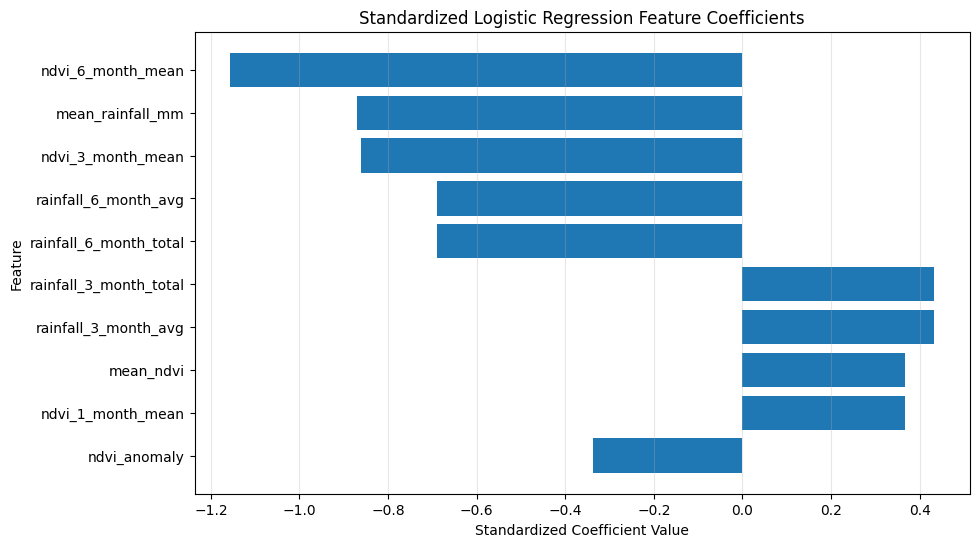

In [16]:
# Visualize standardized Logistic Regression coefficients
plt.figure(figsize=(10, 6))

plt.barh(
    standardized_feature_importance["feature"],
    standardized_feature_importance["coefficient"]
)

plt.title("Standardized Logistic Regression Feature Coefficients")
plt.xlabel("Standardized Coefficient Value")
plt.ylabel("Feature")

plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

plt.show()

### Interpretation

The standardized Logistic Regression coefficients show which features had the strongest influence on the model after putting rainfall and NDVI on a similar scale.

The strongest feature was `ndvi_6_month_mean`, followed by `mean_rainfall_mm`, `ndvi_3_month_mean`, and the 6-month rainfall indicators. These negative coefficients suggest that stronger vegetation health and stronger longer-term rainfall conditions reduce the model's likelihood of predicting high food insecurity risk.

This supports the earlier EDA finding that NDVI is an important signal for food insecurity early-warning analysis. In particular, the 3-month and 6-month NDVI means appear to be useful indicators because they capture vegetation health over time.

Some short-term rainfall features have positive coefficients. This should be interpreted carefully because rainfall features are highly related to each other and may also reflect seasonal patterns. The safer conclusion is that longer-term rainfall and NDVI indicators appear more useful than short-term rainfall alone.

Overall, the standardized coefficients make the model more interpretable and show that the model is learning meaningful environmental patterns.

## Baseline Model 3: Random Forest Classifier

The next model is a Random Forest Classifier.

A Random Forest is made of many decision trees. Each tree makes a prediction, and the forest combines their votes to produce the final prediction.

This model can capture more flexible patterns than Logistic Regression, such as interactions between rainfall and NDVI features.

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Predict probabilities for ROC-AUC
y_pred_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the model
rf_results = {
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "precision": precision_score(y_test, y_pred_rf),
    "recall": recall_score(y_test, y_pred_rf),
    "f1_score": f1_score(y_test, y_pred_rf),
    "roc_auc": roc_auc_score(y_test, y_pred_prob_rf)
}

rf_results

{'accuracy': 0.8769230769230769,
 'precision': 0.7222222222222222,
 'recall': 0.8125,
 'f1_score': 0.7647058823529411,
 'roc_auc': 0.9285714285714286}

### Interpretation

The Random Forest model performed strongly as a baseline model.

It achieved about 87.7% accuracy, 72.2% precision, 81.3% recall, 76.5% F1-score, and 92.9% ROC-AUC.

Compared with Logistic Regression, the Random Forest model improved accuracy, precision, and F1-score. This means it made fewer false alarms and had a better overall balance between identifying high-risk cases and avoiding incorrect high-risk predictions.

However, its recall was lower than Logistic Regression. This means Random Forest missed more true high-risk cases than Logistic Regression.

For an early-warning system, this creates an important trade-off. Logistic Regression is better if the priority is catching as many crises as possible. Random Forest is better if the goal is a more balanced model with fewer false alarms.

## Baseline Model 4: XGBoost Classifier

The next model is XGBoost.

XGBoost is a tree-based machine learning model that builds many small decision trees in sequence. Each new tree tries to correct the mistakes made by the previous trees.

This makes XGBoost more advanced than a single decision tree and different from Random Forest. Random Forest builds many trees independently, while XGBoost builds trees step by step, with each tree learning from earlier errors.

This model can capture more complex relationships between rainfall, NDVI, and food insecurity risk.

Because the dataset is relatively small, I use conservative settings to reduce overfitting. Overfitting happens when a model learns the training data too closely and performs poorly on new data.

The `scale_pos_weight` parameter is used to help the model pay more attention to the high-risk class, since high-risk cases are fewer than non-high-risk cases.

The `min_child_weight` and `gamma` parameters make the model stricter when creating new tree splits. This helps prevent the model from creating very small or weak splits that may not generalize well.

In [20]:
from xgboost import XGBClassifier

# Calculate class imbalance weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Create XGBoost model with conservative settings
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    min_child_weight=5,
    gamma=1
)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Predict probabilities for ROC-AUC
y_pred_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate XGBoost
xgb_results = {
    "accuracy": accuracy_score(y_test, y_pred_xgb),
    "precision": precision_score(y_test, y_pred_xgb),
    "recall": recall_score(y_test, y_pred_xgb),
    "f1_score": f1_score(y_test, y_pred_xgb),
    "roc_auc": roc_auc_score(y_test, y_pred_prob_xgb)
}

xgb_results

{'accuracy': 0.8769230769230769,
 'precision': 0.7,
 'recall': 0.875,
 'f1_score': 0.7777777777777778,
 'roc_auc': 0.9362244897959183}

### Interpretation

The XGBoost model performed strongly on the test set.

It achieved about 87.7% accuracy, 70.0% precision, 87.5% recall, 77.8% F1-score, and 93.6% ROC-AUC.

Compared with Random Forest, XGBoost achieved the same accuracy but improved recall, F1-score, and ROC-AUC. This means it was better at catching high-risk cases while still maintaining good overall performance.

Compared with Logistic Regression, XGBoost produced fewer false alarms while still identifying most true high-risk cases.

Overall, XGBoost is the strongest balanced model so far. It provides a good trade-off between early-warning sensitivity and prediction precision.

## Model Comparison

This table compares all baseline models using the same test set.

The goal is not only to find the highest accuracy, but also to compare precision, recall, F1-score, and ROC-AUC.

For this early-warning project, recall is especially important because missing a real high-risk case can delay response. However, precision also matters because too many false alarms can reduce trust in the model.

In [21]:
# Compare all model results
model_results = pd.DataFrame({
    "Naive Baseline": naive_results,
    "Logistic Regression": log_results,
    "Standardized Logistic Regression": standardized_log_results,
    "Random Forest": rf_results,
    "XGBoost": xgb_results
}).T

model_results

,accuracy,precision,recall,f1_score,roc_auc
Naive Baseline,0.753846,0.000000,0.0000,0.000000,0.500000
Logistic Regression,0.769231,0.517241,0.9375,0.666667,0.917092
Standardized Logistic Regression,0.769231,0.517241,0.9375,0.666667,0.929847
Random Forest,0.876923,0.722222,0.8125,0.764706,0.928571
XGBoost,0.876923,0.700000,0.8750,0.777778,0.936224


### Interpretation

The model comparison shows that the Naive Baseline is not useful for early warning. Although it achieved about 75.4% accuracy, it failed to identify any high-risk cases. This confirms that accuracy alone is misleading for this project.

Logistic Regression achieved the highest recall at 93.75%, meaning it was the best model for catching true high-risk cases. However, its precision was lower, meaning it produced more false alarms.

Random Forest improved accuracy, precision, and F1-score compared with Logistic Regression. This made it a stronger balanced model, but its recall was lower.

XGBoost achieved the strongest overall balance. It matched Random Forest on accuracy, improved recall, achieved the highest F1-score, and produced the highest ROC-AUC score. This suggests that XGBoost is the best balanced baseline model in this experiment.

Overall, Logistic Regression is useful when the main priority is maximum crisis detection, while XGBoost is the best balanced model for combining strong recall with fewer false alarms.

## Model Performance Visualization

To make the model comparison easier to understand, I visualize the key evaluation metrics across all baseline models.

For this early-warning project, the most important metrics are Recall, F1-score, and ROC-AUC:

- **Recall** shows how well the model catches true high-risk cases.
- **F1-score** balances recall and precision.
- **ROC-AUC** shows how well the model separates high-risk from non-high-risk cases.

The chart below helps compare the models more clearly than a table alone.

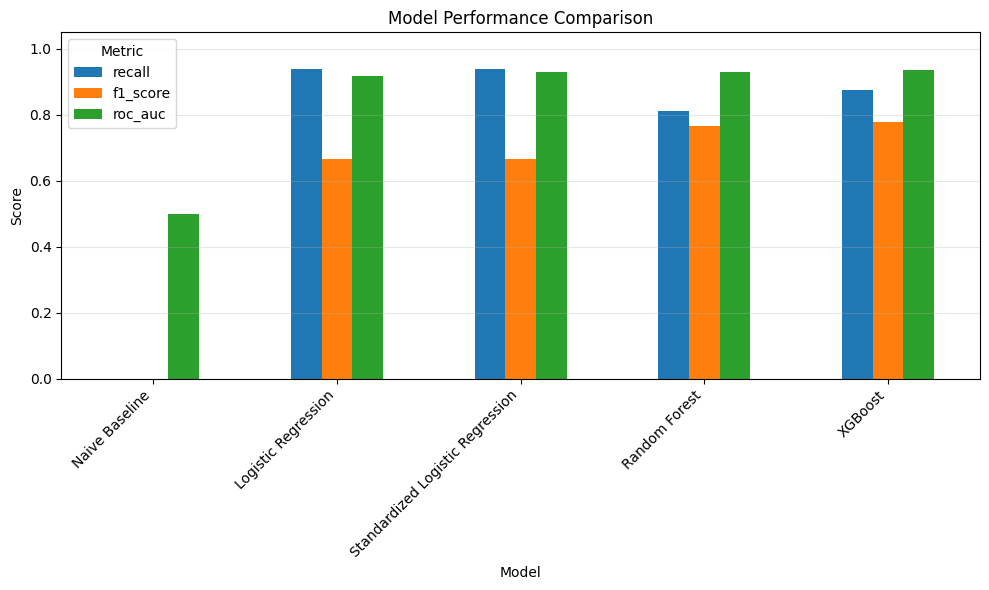

In [22]:
# Select key metrics for visualization
key_metrics = ["recall", "f1_score", "roc_auc"]

# Prepare data for plotting
model_results_viz = model_results[key_metrics]

# Create grouped bar chart
ax = model_results_viz.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.xticks(rotation=45, ha="right")
plt.legend(title="Metric")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The model performance chart shows that the Naive Baseline performs poorly on the most important early-warning metrics because it fails to identify high-risk cases.

Logistic Regression has the highest recall, meaning it is very strong at catching true high-risk cases. However, its F1-score is lower because it produces more false alarms.

Random Forest performs better than Logistic Regression on F1-score, showing a stronger balance between precision and recall.

XGBoost provides the best overall balance. It achieves strong recall, the highest F1-score, and the highest ROC-AUC. This makes it the strongest balanced baseline model in this experiment.

## Final Model Selection

Based on the model comparison, XGBoost is selected as the strongest balanced baseline model.

XGBoost achieved the best overall balance between recall, F1-score, and ROC-AUC. It identified most high-risk cases while also reducing false alarms compared with Logistic Regression.

Logistic Regression had the highest recall, which means it was very strong at catching true high-risk cases. However, it also produced more false alarms.

Random Forest also performed strongly, but XGBoost achieved better recall, F1-score, and ROC-AUC.

For this baseline experiment, XGBoost is selected as the preferred model because it provides the best balance between early-warning sensitivity and prediction reliability.

## XGBoost Confusion Matrix

The confusion matrix shows how the selected XGBoost model performed on the test set.

It helps show how many cases were correctly classified, how many false alarms were created, and how many true high-risk cases were missed.

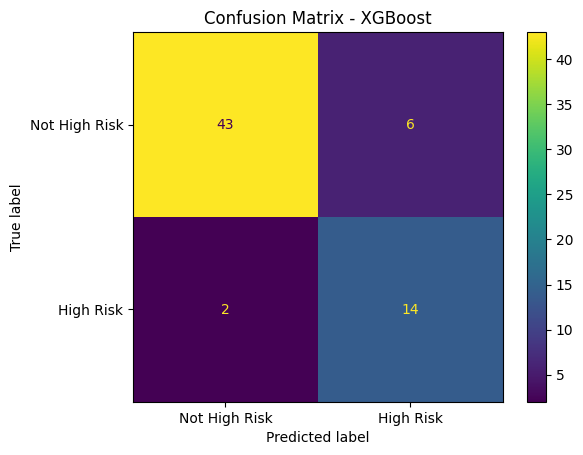

array([[43,  6],
       [ 2, 14]])

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix for XGBoost
xgb_cm = confusion_matrix(y_test, y_pred_xgb)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=xgb_cm,
    display_labels=["Not High Risk", "High Risk"]
)

disp.plot()
plt.title("Confusion Matrix - XGBoost")
plt.show()

xgb_cm

### Interpretation

The XGBoost confusion matrix shows that the model correctly predicted 43 non-high-risk cases and 14 high-risk cases.

The model produced 6 false alarms, meaning 6 non-high-risk cases were incorrectly flagged as high risk. It missed 2 true high-risk cases.

This means XGBoost correctly identified 14 out of 16 high-risk cases in the test set. This is strong performance for a baseline early-warning model.

Compared with Logistic Regression, XGBoost produces fewer false alarms while still catching most high-risk cases. This supports selecting XGBoost as the best balanced baseline model.

## XGBoost Feature Importance

After selecting XGBoost as the strongest balanced baseline model, I check which features were most important to the model.

Feature importance helps explain which rainfall and NDVI indicators contributed most to the model's predictions.

This is important because an early-warning model should not only make predictions, but also help stakeholders understand the environmental signals behind those predictions.

In [24]:
# Create XGBoost feature importance table
xgb_feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
})

# Sort by importance
xgb_feature_importance = xgb_feature_importance.sort_values(
    "importance",
    ascending=False
)

xgb_feature_importance

,feature,importance
8,ndvi_6_month_mean,0.217117
2,rainfall_6_month_total,0.135436
7,ndvi_3_month_mean,0.120919
4,rainfall_6_month_avg,0.103252
6,ndvi_1_month_mean,0.096913
9,ndvi_anomaly,0.073270
3,rainfall_3_month_avg,0.072350
0,mean_rainfall_mm,0.069587
1,rainfall_3_month_total,0.057616
5,mean_ndvi,0.053539


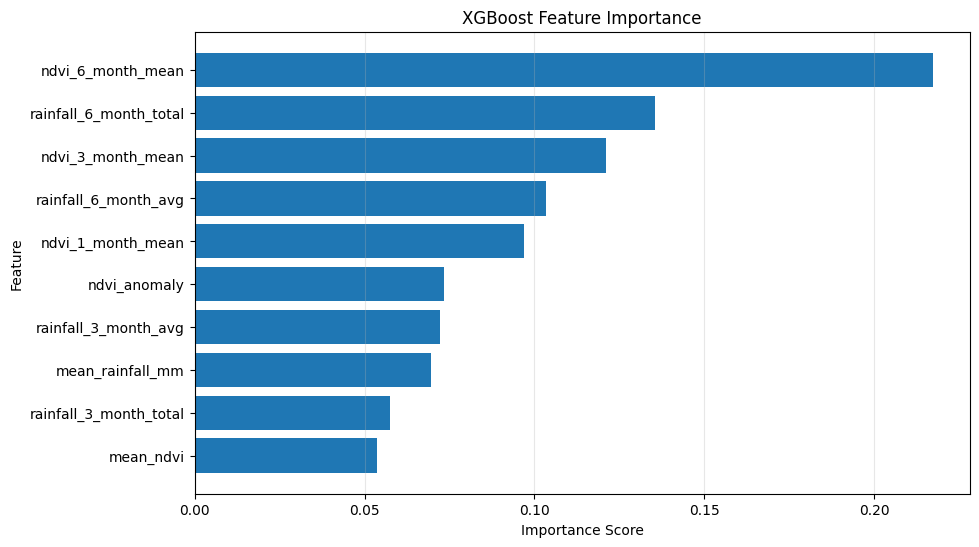

In [25]:
# Visualize XGBoost feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    xgb_feature_importance["feature"],
    xgb_feature_importance["importance"]
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

plt.show()

### Interpretation

The XGBoost feature importance chart shows that the model relied most on longer-term vegetation and rainfall indicators.

The most important feature was `ndvi_6_month_mean`, followed by `rainfall_6_month_total`, `ndvi_3_month_mean`, and `rainfall_6_month_avg`. This suggests that medium-term environmental conditions, especially vegetation health and 6-month rainfall patterns, are useful for identifying high food insecurity risk.

This supports the earlier exploratory analysis, where NDVI indicators showed strong relationships with Phase 3+ food insecurity burden. The model also confirms that rainfall remains important, especially when measured over longer periods.

Feature importance shows which variables helped the model make predictions, but it does not show whether a feature increases or decreases risk. For direction, the correlation analysis and Logistic Regression coefficients are more useful.

Overall, the XGBoost model appears to be learning meaningful environmental signals rather than relying on random patterns.

## Notebook Conclusion

This notebook built and compared several baseline machine learning models for food insecurity early-warning analysis in Kenya ASAL counties.

The target variable was defined as `high_risk`, where a county-period is classified as high risk if 20% or more of the population is in IPC Phase 3 or worse.

A time-aware train-test split was used so that the models learned from earlier records and were tested on later records. This better reflects a real early-warning setting, where past data is used to predict future risk.

The Naive Baseline showed why accuracy alone is misleading. Although it achieved reasonable accuracy by always predicting the most common class, it failed to identify any high-risk cases.

Logistic Regression achieved the highest recall, meaning it was very good at catching true high-risk cases. However, it also produced more false alarms.

Random Forest improved overall balance by increasing precision and F1-score compared with Logistic Regression.

XGBoost achieved the strongest balanced performance overall. It matched Random Forest on accuracy, improved recall, achieved the highest F1-score, and produced the highest ROC-AUC score.

Based on this baseline experiment, XGBoost is selected as the preferred balanced model for this project.

The feature importance results show that longer-term vegetation and rainfall indicators were important for prediction, especially `ndvi_6_month_mean`, `rainfall_6_month_total`, `ndvi_3_month_mean`, and `rainfall_6_month_avg`.

Overall, the results suggest that rainfall and NDVI indicators contain useful signals for identifying food insecurity risk. The next stage of the project should focus on improving the model, testing additional features, and validating performance across more time periods.

## Next Steps

Future improvements can include:

1. Adding food price indicators, such as cereal market prices.
2. Testing more time-lagged features to improve early-warning performance.
3. Comparing additional models and tuning model parameters.
4. Evaluating the model using county-level maps and risk tables.
5. Building a simple dashboard to show predicted high-risk counties.
6. Testing the model on future IPC periods as new data becomes available.

This baseline notebook provides the first machine learning foundation for the drought and food security early-warning system.